# Interactive 3D plotting

Notebooks [01](01_basics.ipynb)–[05](05_populations_and_stats.ipynb) save their
figures as static PNGs so they render on GitHub. This one is about the **live**
renderer: a rotatable, zoomable 3D view of a neuron, and the overlay and
annotation functions that only really pay off when you can move the camera.

Everything here uses the bundled sample reconstruction, so the notebook runs
anywhere with no external data files.

## Setup: the two Jupyter backends

3D rendering needs the `plot` extra:

```bash
pip install -e ".[plot]"
```

PyVista can then draw into a notebook two ways:

| Backend | What you get | When |
|---|---|---|
| `"static"` | A rendered image per plot | Committed notebooks, CI, GitHub — the output survives without a kernel |
| `"trame"` | A live widget you can rotate, zoom and pan | Actually exploring a morphology |

`trame` needs `trame`, `trame-vtk`, `trame-vuetify` and `ipywidgets` — all in
[`requirements.txt`](../requirements.txt).

This notebook is executed with `"static"` so the images below are real and
visible on GitHub. **Change the one line in the next cell to `"trame"` and
every plot becomes interactive** — no other edit needed.

In [1]:
import time

import numpy as np
import pyvista as pv

import pytrees as pt

pv.set_jupyter_backend("static")      # <-- change to "trame" for live widgets
pv.global_theme.window_size = [560, 420]

tree = pt.sample_tree()
tree

Tree(name='sample', n_nodes=2252, regions=[1])

## Your first plot

`plot_tree` builds the mesh and returns a `pyvista.Plotter`. It does **not**
draw anything by itself — MATLAB's `'-s'` show-as-a-side-effect option is
deliberately gone. You call `.show()` when you're ready, which means you can
keep adding to the scene first.

That separation is the whole reason the overlays further down are this easy.

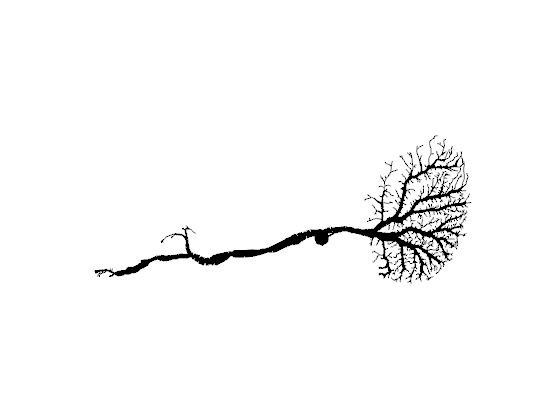

In [2]:
pl = pt.plot_tree(tree, color="black")
pl.camera_position = "xy"
pl.show()

## Colouring by any per-node quantity

`scalars=` takes any array of length `n_nodes` — a metric you just computed, a
region code, anything. This is the single most useful thing the 3D view does.

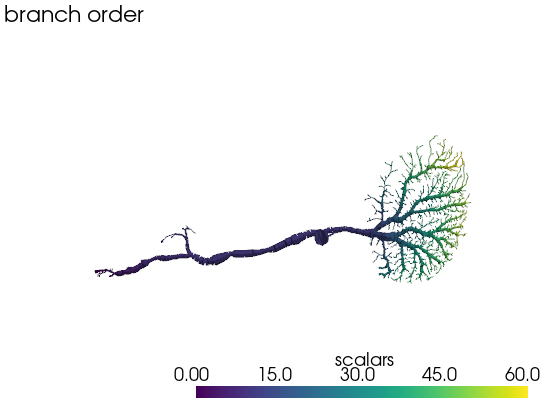

In [3]:
bo = pt.BO_tree(tree).astype(float)

pl = pt.plot_tree(tree, scalars=bo, cmap="viridis")
pl.add_text("branch order", font_size=10)
pl.camera_position = "xy"
pl.show()

> `scalars` is always the **whole tree's** array, even when `nodes=` restricts
> what gets drawn. A wrong-length array raises a clear `ValueError` rather than
> mis-colouring silently.

## `tube` vs `line`

`mode="tube"` (the default) builds a diameter-tapered tube — anatomically
honest, and still one mesh no matter how many segments. `mode="line"` skips
tubing: no diameters, but a far smaller mesh.

The build-time difference on a single cell is modest. What actually changes is
the **mesh size** — around 30× — and that is what you feel when rotating a big
scene, holding a population in memory, or writing the thing to disk. The gap in
build time widens as the scene grows, too, so `"line"` is the right default for
whole populations and fast iteration.

MATLAB's `plot_tree.m` runs a singular value decomposition *per segment* to
build the same geometry, and its own source comment calls that loop a
bottleneck. VTK's `tube()` filter does it as one compiled operation.

In [4]:
# Warm up first: the very first render of a session pays one-off VTK pipeline
# initialisation that has nothing to do with the mode being compared.
for mode in ("tube", "line"):
    pt.plot_tree(tree, mode=mode).close()

print(f"one cell ({tree.n_nodes:,} nodes)")
for mode in ("tube", "line"):
    t0 = time.perf_counter()
    pl = pt.plot_tree(tree, mode=mode)
    dt = (time.perf_counter() - t0) * 1e3
    print(f"  {mode:5s} {dt:6.1f} ms   {pl.mesh.n_points:,} mesh points")
    pl.close()

# ...and the same comparison for a scene of eight cells
population = pt.spread_trees([tree] * 8)
print(f"\neight cells ({sum(t.n_nodes for t in population):,} nodes)")
for mode in ("tube", "line"):
    t0 = time.perf_counter()
    pl = None
    for cell in population:
        pl = pt.plot_tree(cell, mode=mode, plotter=pl)
    print(f"  {mode:5s} {(time.perf_counter() - t0) * 1e3:6.1f} ms")
    pl.close()

one cell (2,252 nodes)
  tube    79.8 ms   72,032 mesh points
  line    55.5 ms   2,252 mesh points

eight cells (18,016 nodes)


  tube   264.5 ms
  line   134.9 ms


## Overlaying: `plotter=`

Pass an existing plotter and the next tree is added to the same scene — this is
the equivalent of MATLAB's `hold on`. Combined with `nodes=`, it's how you
highlight part of a cell against the rest of it.

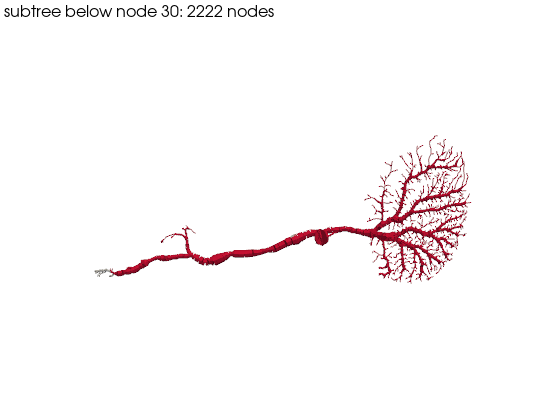

In [5]:
node = int(np.flatnonzero(pt.B_tree(tree))[5])
mask = pt.sub_tree(tree, node)          # this node and every descendant

pl = pt.plot_tree(tree, color="lightgray")
pl = pt.plot_tree(tree, color="crimson", nodes=np.flatnonzero(mask), plotter=pl)
pl.add_text(f"subtree below node {node}: {mask.sum()} nodes", font_size=10)
pl.camera_position = "xy"
pl.show()

## Marking and labelling nodes

`pointer_tree` marks locations (recording sites, synapses, points of interest);
`vtext_tree` writes text at them, defaulting to the node index.

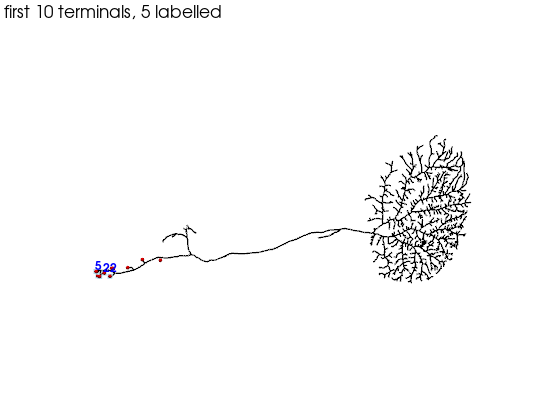

In [6]:
tips = np.flatnonzero(pt.T_tree(tree))[:10]

pl = pt.plot_tree(tree, color="black", mode="line")
pt.pointer_tree(pl, tree, tips, style="sphere", color="red", size=4.0)
pt.vtext_tree(pl, tree, nodes=tips[:5], color="blue", font_size=12)
pl.add_text("first 10 terminals, 5 labelled", font_size=10)
pl.camera_position = "xy"
pl.show()

## Convex hull

`chull_tree` returns the points and a SciPy `ConvexHull`, and draws the hull
surface if you hand it a plotter.

It returns `(points, None)` — rather than raising — whenever no hull can exist:
too few points, or a **planar** tree. That second case is common (2D-traced
reconstructions, and anything out of `flatten_tree`), so pass `dim2=True` there
to get the enclosed area instead.

hull volume: 4,621,652 um^3
hull area  : 289,777 um^2


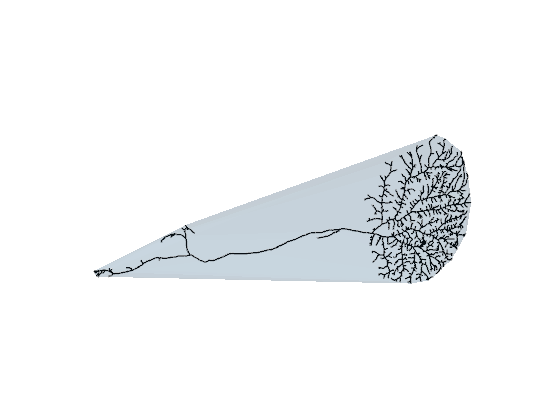

In [7]:
pl = pt.plot_tree(tree, color="black", mode="line")
pts, hull = pt.chull_tree(tree, plotter=pl, color="steelblue", opacity=0.15)

print(f"hull volume: {hull.volume:,.0f} um^3")
print(f"hull area  : {hull.area:,.0f} um^2")

pl.camera_position = "xy"
pl.show()

## Several cells in one scene

`spread_trees` lays a list of trees out on a rough grid by bounding box and
returns translated copies, so they don't overlap. Feed them to the same plotter
one at a time.

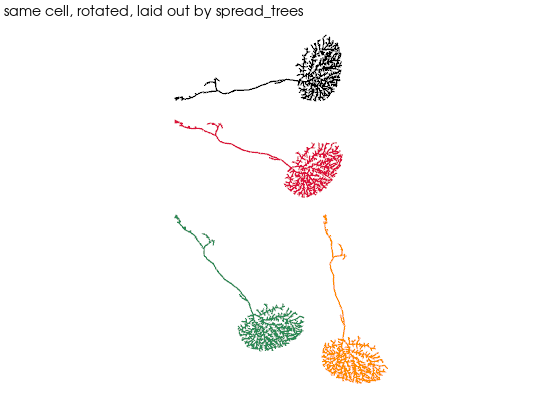

In [8]:
copies = [pt.rot_tree(tree, (0.0, 0.0, angle)) for angle in (0, 30, 60, 90)]
laid_out = pt.spread_trees(copies, dx=80.0, dy=80.0)

pl = None
for t, colour in zip(laid_out, ("black", "crimson", "seagreen", "darkorange")):
    pl = pt.plot_tree(t, color=colour, mode="line", plotter=pl)

pl.add_text("same cell, rotated, laid out by spread_trees", font_size=10)
pl.camera_position = "xy"
pl.show()

## The abstract counterpart: dendrograms

Not everything worth seeing is spatial. `dendrogram_tree` throws the
coordinates away and plots pure topology against path length — branch structure
you can't read off a 3D render. It's matplotlib, not PyVista, because it isn't
a 3D scene.

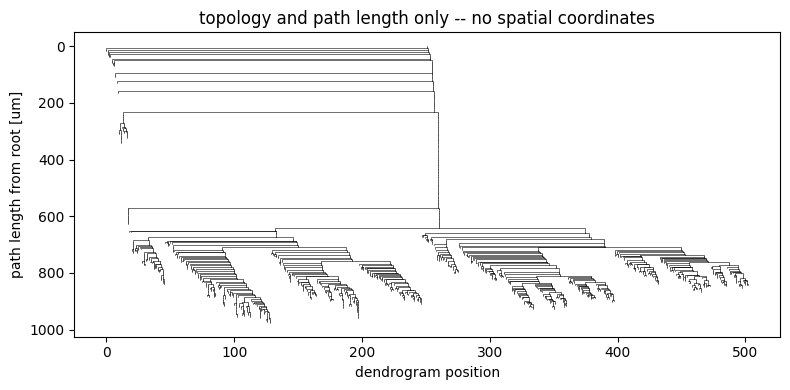

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
pt.dendrogram_tree(tree, ax=ax, linewidth=0.4)
ax.set_title("topology and path length only -- no spatial coordinates")
plt.tight_layout()
plt.show()

## Saving images, and running headless

Set `camera_position` before rendering (`"xy"`, `"yz"`, `"xz"`, or an explicit
camera triple), then `screenshot()`.

On a server or in CI with no display, don't call `.show()` at all: `plot_tree`
already creates its plotter with `off_screen=True` whenever `show=False` (the
default), so `screenshot()` works with no window manager involved. That's the
pattern notebooks 01–05 use.

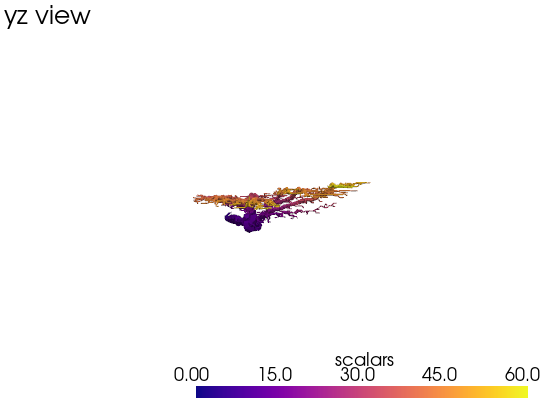

In [10]:
pl = pt.plot_tree(tree, scalars=bo, cmap="plasma")
pl.camera_position = "yz"          # look down the X axis instead
pl.add_text("yz view", font_size=10)
pl.screenshot("plot_yz_view.png")  # no .show() -- nothing needs a display
pl.close()

from IPython.display import Image
Image("plot_yz_view.png")

## Troubleshooting

| Symptom | Cause |
|---|---|
| Nothing appears, no error | Backend is `"trame"` but `trame`/`ipywidgets` aren't installed. `pip install -r requirements.txt` |
| Widget renders empty on GitHub | Expected — widgets need a live kernel. Use `"static"` for anything you commit |
| `ImportError: needs pyvista` | Install the extra: `pip install -e ".[plot]"` |
| Blank or black image on a headless Linux box | Call `pv.start_xvfb()` before plotting |
| Notebook file is very large | Each `"static"` plot embeds an image. Lower `pv.global_theme.window_size`, or switch to `screenshot()` + `Image()` |

For a quick look without PyVista at all, `plot_tree_mpl` draws a line-only
preview through matplotlib — see [`docs/guide.md`](../docs/guide.md).

**Back to:** [`01_basics.ipynb`](01_basics.ipynb) ·
**Next:** [`02_editing_and_construction.ipynb`](02_editing_and_construction.ipynb)